# Práctica 1 — Ejercicio 2: Años de educación y esperanza de vida

Se desea estudiar la relación entre los **años de educación** y la **esperanza de vida**. Para ello se cuenta con un dataset de datos del año 2015.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
# Cargar y filtrar datos (ano 2015)
df_vida = pd.read_csv("../Datasets/Parte_1/estudio_vida.csv")
df_vida.columns = df_vida.columns.str.strip()

df = df_vida[df_vida["Year"] == 2015][["Country", "Life expectancy", "Schooling"]].copy()
df.columns = ["Country", "Life_expectancy", "Schooling"]
df = df.dropna(subset=["Life_expectancy", "Schooling"])
print(f"Observaciones en 2015 (sin NAs): {len(df)}")
print(df[["Life_expectancy", "Schooling"]].describe())

Observaciones en 2015 (sin NAs): 173
       Life_expectancy   Schooling
count       173.000000  173.000000
mean         71.712717   12.927168
std           7.933500    2.912366
min          51.000000    4.900000
25%          66.000000   10.800000
50%          73.900000   13.100000
75%          76.700000   15.000000
max          88.000000   20.400000


## Análisis exploratorio

> **Proponga un análisis exploratorio de los datos y comente la relación que se puede observar entre las variables. ¿Es posible ajustar un modelo de regresión simple entre estas variables?**

Correlacion de Pearson: 0.8182 (p-valor: 5.9270e-43)


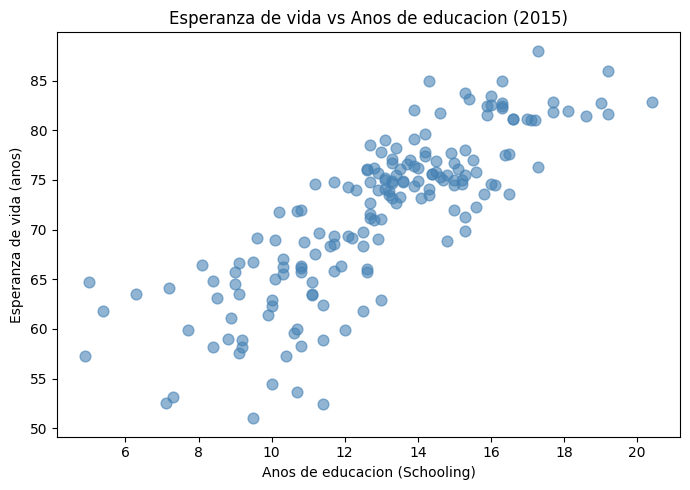

In [3]:
# Correlacion de Pearson
r, p_val = stats.pearsonr(df["Schooling"], df["Life_expectancy"])
print(f"Correlacion de Pearson: {r:.4f} (p-valor: {p_val:.4e})")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["Schooling"], df["Life_expectancy"], color="steelblue", alpha=0.6, s=60)
ax.set_xlabel("Anos de educacion (Schooling)")
ax.set_ylabel("Esperanza de vida (anos)")
ax.set_title("Esperanza de vida vs Anos de educacion (2015)")
plt.tight_layout()
plt.show()

**Observaciones:**
- Existe una correlacion positiva y fuerte entre los anos de educacion y la esperanza de vida (r ≈ 0.82).
- El grafico de dispersion muestra una tendencia lineal creciente: a mayor nivel educativo, mayor esperanza de vida.
- Es razonable ajustar un modelo de regresion lineal simple.

## Ajuste del modelo

> **Indique cuál sería el modelo propuesto en relación al problema que busca modelizar y ajústelo con las librerías propuestas en clase. Explique las salidas del modelo (coeficientes, R², y lo que le parezca pertinente).**

In [4]:
mod = smf.ols("Life_expectancy ~ Schooling", data=df)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_expectancy   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     346.2
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           5.93e-43
Time:                        18:17:43   Log-Likelihood:                -507.54
No. Observations:                 173   AIC:                             1019.
Df Residuals:                     171   BIC:                             1025.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     42.9016      1.587     27.033      0.0

In [5]:
b0 = res.params["Intercept"]
b1 = res.params["Schooling"]
print(f"Modelo ajustado: Life_expectancy = {b0:.4f} + {b1:.4f} * Schooling")
print(f"R2 = {res.rsquared:.4f}")
print(f"Por cada ano adicional de educacion, la esperanza de vida aumenta {b1:.4f} anos.")

Modelo ajustado: Life_expectancy = 42.9016 + 2.2287 * Schooling
R2 = 0.6694
Por cada ano adicional de educacion, la esperanza de vida aumenta 2.2287 anos.


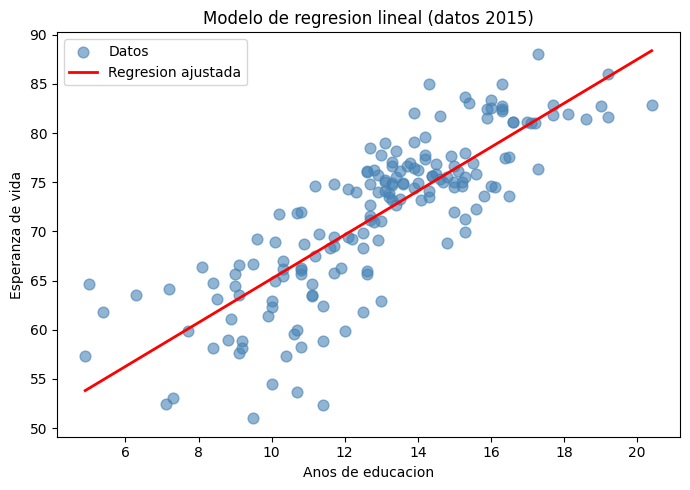

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["Schooling"], df["Life_expectancy"], color="steelblue", alpha=0.6, s=60, label="Datos")
s_seq = np.linspace(df["Schooling"].min(), df["Schooling"].max(), 200)
ax.plot(s_seq, res.predict(pd.DataFrame({"Schooling": s_seq})), color="red", lw=2, label="Regresion ajustada")
ax.set_xlabel("Anos de educacion")
ax.set_ylabel("Esperanza de vida")
ax.set_title("Modelo de regresion lineal (datos 2015)")
ax.legend()
plt.tight_layout()
plt.show()

## Análisis de residuos

> **Proponga un análisis de residuos.**

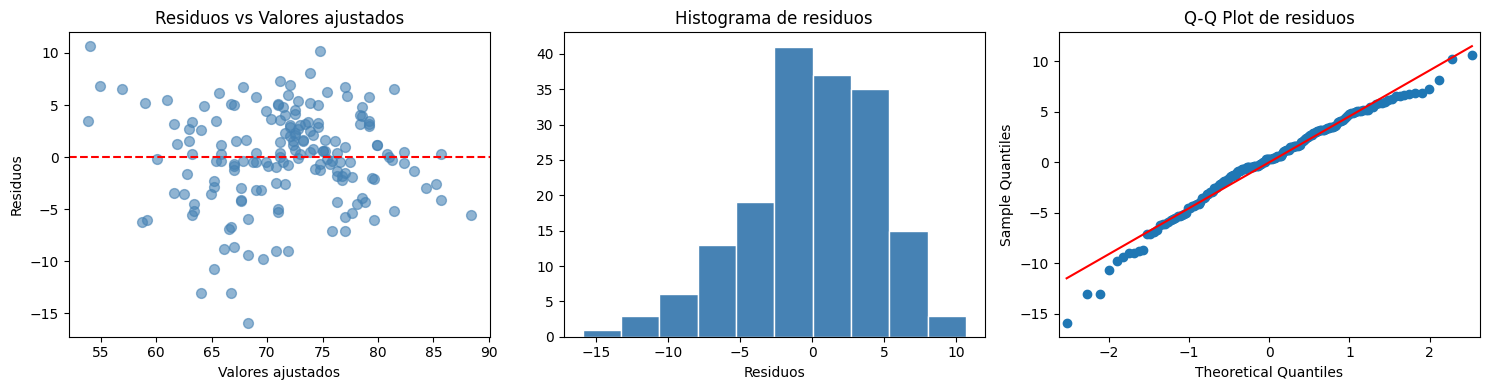

Shapiro-Wilk: W=0.9775, p-valor=0.0066
Conclusion: Se rechaza normalidad (p <= 0.05)


In [7]:
residuos = res.resid
fitted   = res.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(fitted, residuos, color="steelblue", alpha=0.6, s=50)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valores ajustados")
axes[0].set_ylabel("Residuos")
axes[0].set_title("Residuos vs Valores ajustados")

axes[1].hist(residuos, bins=10, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residuos")
axes[1].set_title("Histograma de residuos")

sm.qqplot(residuos, line="s", ax=axes[2])
axes[2].set_title("Q-Q Plot de residuos")
plt.tight_layout()
plt.show()

stat_sw, p_sw = stats.shapiro(residuos)
print(f"Shapiro-Wilk: W={stat_sw:.4f}, p-valor={p_sw:.4f}")
print("Conclusion:", "No se rechaza normalidad (p > 0.05)" if p_sw > 0.05
      else "Se rechaza normalidad (p <= 0.05)")

## Conclusiones

> **Escriba sus conclusiones al respecto.**

El modelo de regresión lineal ajustado es:

$$\hat{esperanza\_de\_vida} = 42.90 + 2.23 \cdot \text{Schooling}$$

- **Intercepto (β₀ = 42.90):** La esperanza de vida predicha para un país con 0 años de educación
  formal sería de aproximadamente 42.90 años (valor de referencia teórico).
- **Pendiente (β₁ = 2.23):** Por cada año adicional promedio de educación, la esperanza de vida
  predicha aumenta en 2.23 años, manteniendo constantes los demás factores.
- **R² = 0.669:** El modelo explica el 66.9% de la variabilidad en la esperanza de vida entre países.
  Existe una asociación estadísticamente significativa (p < 0.001) pero moderada-alta.
- **Residuos:** El test de Shapiro-Wilk rechaza la normalidad de los residuos (p = 0.007),
  lo que puede indicar la presencia de valores atípicos o que la relación no es perfectamente lineal.
  No obstante, con n=173 el Teorema Central del Límite garantiza la validez asintótica de las inferencias.